In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
fileName = r"C:\Users\justi\OneDrive\Documents\GEOL_415\Assignments\09-09\LA_AQS_2023.csv"
df = pd.read_csv(fileName)

df = pd.read_csv(fileName)
df['Parameter Name']

0           Ambient Min Temperature
1            Nitrogen dioxide (NO2)
2                 Relative Humidity
3               Outdoor Temperature
4          Oxides of nitrogen (NOx)
                    ...            
22155               Solar radiation
22156    Wind Direction - Resultant
22157        Wind Speed - Resultant
22158             Relative Humidity
22159           Outdoor Temperature
Name: Parameter Name, Length: 22160, dtype: str

In [3]:
data = df[df['Parameter Name'].isin(['Ozone', 'Nitrogen dioxide (NO2)'])].copy()

In [4]:
o3 = data[data['Parameter Name'] == 'Ozone'][['Date (Local)', 'Arithmetic Mean']]
o3 = o3.rename(columns={'Arithmetic Mean': 'O3'})

no2 = data[data['Parameter Name'] == 'Nitrogen dioxide (NO2)'][['Date (Local)', 'Arithmetic Mean']]
no2 = no2.rename(columns={'Arithmetic Mean': 'NO2'})

In [5]:
data = pd.merge(o3, no2, on='Date (Local)')

In [6]:
data = data.dropna(subset=['O3', 'NO2'])

In [7]:
X = data[['NO2']]
y = data['O3']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [8]:
model = linear_model.LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['NO2']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.03881
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [9]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [10]:
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

print("Training R²:", r2_score(y_train, y_train_pred))
print("Testing R²:", r2_score(y_test, y_test_pred))

print("Testing RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

Slope: -0.000737642132756429
Intercept: 0.038807275279263115
Training R²: 0.3358695264265408
Testing R²: 0.328930405724456
Testing RMSE: 0.0065016034563723


In [11]:
plt.figure(figsize=(9, 6))

<Figure size 900x600 with 0 Axes>

<Figure size 900x600 with 0 Axes>

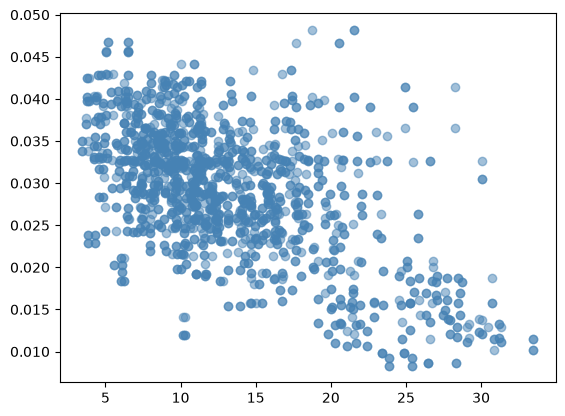

In [12]:
plt.scatter(X_train, y_train, color='steelblue', alpha=0.5, label='Training data')

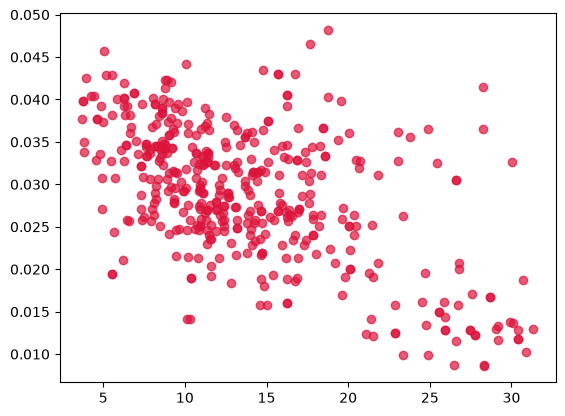

In [13]:
plt.scatter(X_test, y_test, color='crimson', alpha=0.7, label='Testing data')

In [14]:
x_line = pd.DataFrame({'NO2': np.linspace(data['NO2'].min(), data['NO2'].max(), 100)})

y_line = model.predict(x_line)

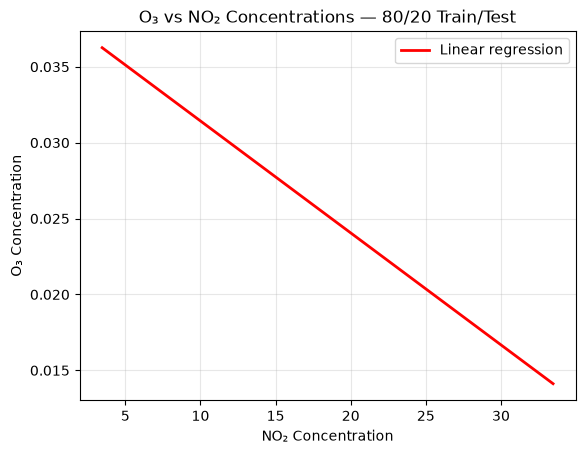

In [15]:
plt.plot(
    x_line,
    y_line,
    color='red',
    linewidth=2,
    label='Linear regression'
)

plt.xlabel('NO₂ Concentration')
plt.ylabel('O₃ Concentration')
plt.title('O₃ vs NO₂ Concentrations — 80/20 Train/Test')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [16]:
test_error = np.sqrt(mean_squared_error(y_test, y_test_pred))
print("Test Error:", test_error)

Test Error: 0.0065016034563723


In [17]:
print(np.sqrt(mean_squared_error(y_test, y_test_pred)))

0.0065016034563723


In [18]:
# Yes, I think a linear model performed well as the test and training data used was quite comparable, as well as the low percentage of error evaluated.

In [19]:
fileName = r"C:\Users\justi\OneDrive\Documents\GEOL_415\Assignments\09-23\ManuaLoa_CO2.csv"
df = pd.read_csv(fileName)

In [20]:
df_CO2 = df['average']

df_CO2 = df[['decimal date', 'average']]
df_CO2.head()

,decimal date,average
0,1958.2027,315.70
1,1958.2877,317.45
2,1958.3699,317.51
3,1958.4548,317.24
4,1958.5370,315.86


In [21]:
df_before_2000 = df_CO2[df_CO2['decimal date'] < 2000].dropna()

X = df_before_2000[['decimal date']]
y = df_before_2000['average']

In [22]:
model = linear_model.LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.32]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['decimal date']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2281
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [23]:
slope = model.coef_[0]
intercept = model.intercept_

print("Slope:", slope)
print("Intercept:", intercept)
print(f"Linear model: CO2 = {slope:.4f} * decimal date + {intercept:.2f}")

Slope: 1.3232892288524036
Intercept: -2280.591072256732
Linear model: CO2 = 1.3233 * decimal date + -2280.59


In [24]:
y_pred = model.predict(X)

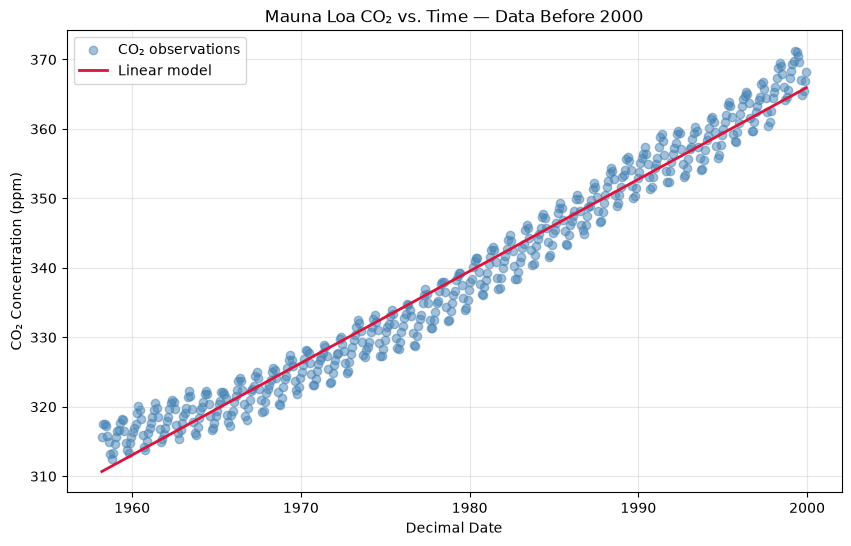

In [25]:
plt.figure(figsize=(10, 6))

plt.scatter(X, y, color='steelblue', alpha=0.5, label='CO₂ observations')

plt.plot(X, y_pred, color='crimson', linewidth=2, label='Linear model')

plt.xlabel('Decimal Date')
plt.ylabel('CO₂ Concentration (ppm)')
plt.title('Mauna Loa CO₂ vs. Time — Data Before 2000')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [26]:
df_after_2000 = df_CO2[df_CO2['decimal date'] > 2000].dropna()

X = df_after_2000[['decimal date']]
y = df_after_2000['average']

In [27]:
y_pred = model.predict(X)

In [28]:
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Test R²:", test_r2)
print("Test RMSE:", test_rmse)

Test R²: 0.328930405724456
Test RMSE: 0.0065016034563723


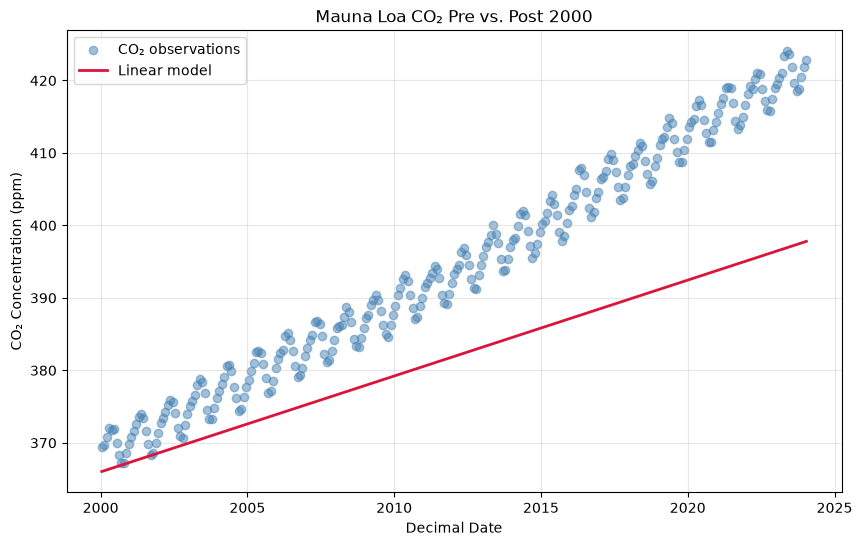

In [29]:
plt.figure(figsize=(10, 6))

plt.scatter(X, y, color='steelblue', alpha=0.5, label='CO₂ observations')

plt.plot(X, y_pred, color='crimson', linewidth=2, label='Linear model')

plt.xlabel('Decimal Date')
plt.ylabel('CO₂ Concentration (ppm)')
plt.title('Mauna Loa CO₂ Pre vs. Post 2000')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [30]:
#I do not think the linear model did as well as with the EPA AQS data. This is because, as the years proceed, the linear model continues to proceed at a standard rate, where the actual CO2 levels observed had continued to increase passed previous records.